In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Load datasets
credits       = pd.read_csv('../data/raw/credits.csv')
keywords      = pd.read_csv('../data/raw/keywords.csv')
links         = pd.read_csv('../data/raw/links.csv')
links_small   = pd.read_csv('../data/raw/links_small.csv')
metadata      = pd.read_csv('../data/raw/movies_metadata.csv', low_memory=False)
ratings       = pd.read_csv('../data/raw/ratings_small.csv')

print("All datasets loaded")

All datasets loaded


In [2]:
datasets = {
    'metadata': metadata,
    'credits': credits,
    'keywords': keywords,
    'links': links,
    'links_small': links_small,
    'ratings': ratings
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"📄 {name.upper()}")
    print(f"  Shape     : {df.shape}")
    print(f"  Columns   : {list(df.columns)}")
    print(f"  Nulls     : {df.isnull().sum().sum()} total missing values")
    print(f"  Duplicates: {df.duplicated().sum()}")


📄 METADATA
  Shape     : (45466, 24)
  Columns   : ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']
  Nulls     : 105562 total missing values
  Duplicates: 17

📄 CREDITS
  Shape     : (45476, 3)
  Columns   : ['cast', 'crew', 'id']
  Nulls     : 0 total missing values
  Duplicates: 37

📄 KEYWORDS
  Shape     : (46419, 2)
  Columns   : ['id', 'keywords']
  Nulls     : 0 total missing values
  Duplicates: 987

📄 LINKS
  Shape     : (45843, 3)
  Columns   : ['movieId', 'imdbId', 'tmdbId']
  Nulls     : 219 total missing values
  Duplicates: 0

📄 LINKS_SMALL
  Shape     : (9125, 3)
  Columns   : ['movieId', 'imdbId', 'tmdbId']
  Nulls     : 13 total missing values
  Duplicates: 0

📄 RATINGS
  Shape     :

In [3]:
# Overview of key columns
print(metadata[['title', 'release_date', 'genres', 'vote_average',
                 'vote_count', 'popularity', 'budget', 'revenue']].head(5))

# Data types
print("\nData types:")
print(metadata.dtypes)

# Missing values per column
print("\nMissing values:")
print(metadata.isnull().sum().sort_values(ascending=False))

                         title release_date  \
0                    Toy Story   1995-10-30   
1                      Jumanji   1995-12-15   
2             Grumpier Old Men   1995-12-22   
3            Waiting to Exhale   1995-12-22   
4  Father of the Bride Part II   1995-02-10   

                                              genres  vote_average  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...           7.7   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...           6.9   
2  [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...           6.5   
3  [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...           6.1   
4                     [{'id': 35, 'name': 'Comedy'}]           5.7   

   vote_count popularity    budget      revenue  
0      5415.0  21.946943  30000000  373554033.0  
1      2413.0  17.015539  65000000  262797249.0  
2        92.0    11.7129         0          0.0  
3        34.0   3.859495  16000000   81452156.0  
4       173.0   8.387519         0   76578911.

/var/folders/fv/nd8b4_g50470f0qxgfg6m4qm0000gn/T/ipykernel_84772/1088725105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='Blues_d')


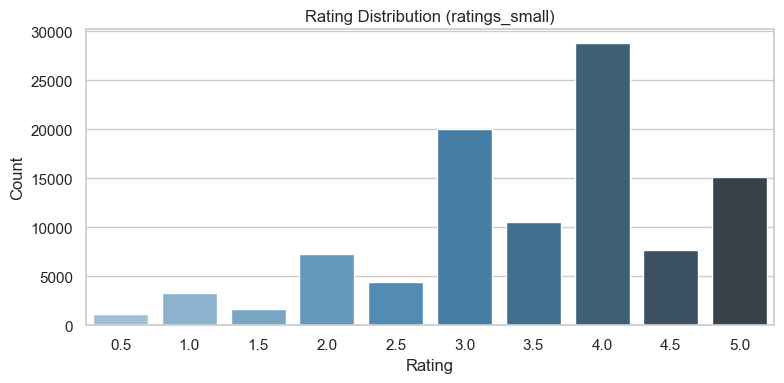

count    100004.000000
mean          3.543608
std           1.058064
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Unique users  : 671
Unique movies : 9066
Total ratings : 100004


In [4]:
plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=ratings, palette='Blues_d')
plt.title('Rating Distribution (ratings_small)')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/rating_distribution.png')
plt.show()

print(ratings['rating'].describe())
print(f"\nUnique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")
print(f"Total ratings : {len(ratings)}")

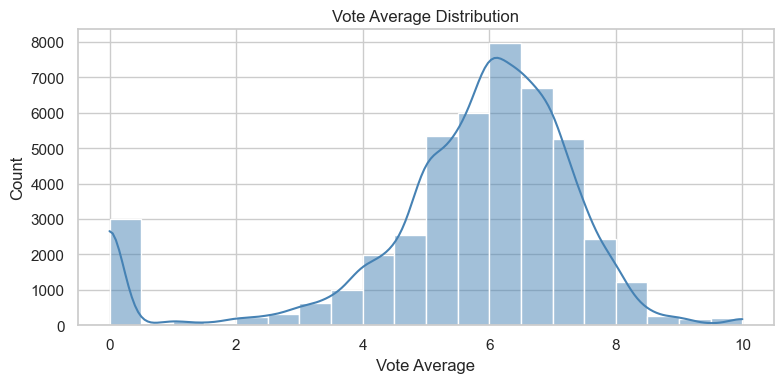

In [5]:
# Convert to numeric safely
metadata['vote_average'] = pd.to_numeric(metadata['vote_average'], errors='coerce')
metadata['vote_count']   = pd.to_numeric(metadata['vote_count'], errors='coerce')

plt.figure(figsize=(8, 4))
sns.histplot(metadata['vote_average'].dropna(), bins=20, kde=True, color='steelblue')
plt.title('Vote Average Distribution')
plt.xlabel('Vote Average')
plt.tight_layout()
plt.savefig('../data/processed/vote_avg_distribution.png')
plt.show()

/var/folders/fv/nd8b4_g50470f0qxgfg6m4qm0000gn/T/ipykernel_84772/694085834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='genre', data=genres_df, palette='viridis')


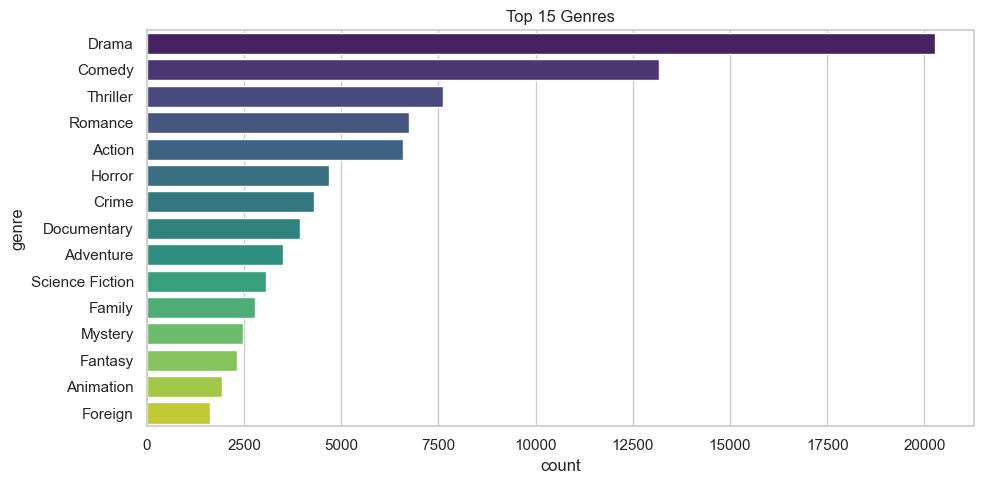

In [6]:
# Parse genres from stringified JSON
def parse_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

metadata['genres_list'] = metadata['genres'].apply(parse_genres)

# Explode and count
from collections import Counter
all_genres = [g for sublist in metadata['genres_list'] for g in sublist]
genre_counts = Counter(all_genres).most_common(15)

genres_df = pd.DataFrame(genre_counts, columns=['genre', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='genre', data=genres_df, palette='viridis')
plt.title('Top 15 Genres')
plt.tight_layout()
plt.savefig('../data/processed/top_genres.png')
plt.show()

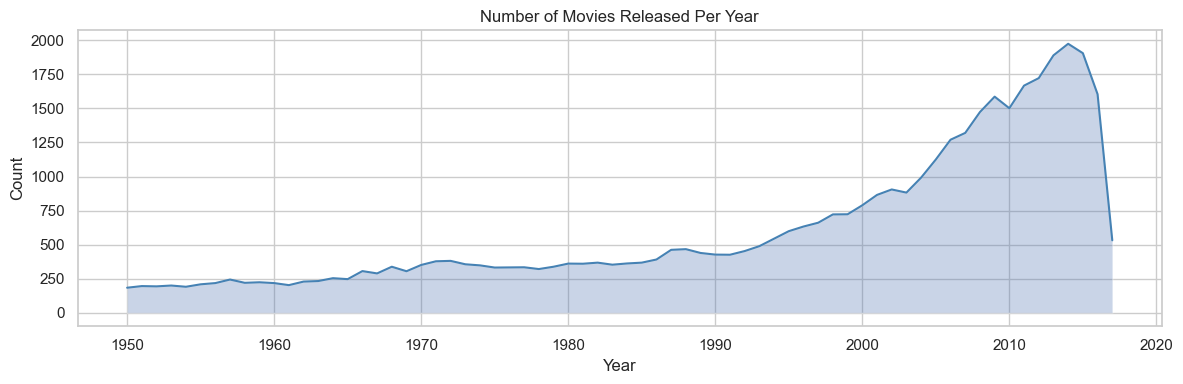

In [7]:
metadata['release_date'] = pd.to_datetime(metadata['release_date'], errors='coerce')
metadata['year'] = metadata['release_date'].dt.year

yearly = metadata['year'].value_counts().sort_index()
yearly = yearly[(yearly.index >= 1950) & (yearly.index <= 2017)]

plt.figure(figsize=(12, 4))
plt.plot(yearly.index, yearly.values, color='steelblue')
plt.fill_between(yearly.index, yearly.values, alpha=0.3)
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/movies_per_year.png')
plt.show()

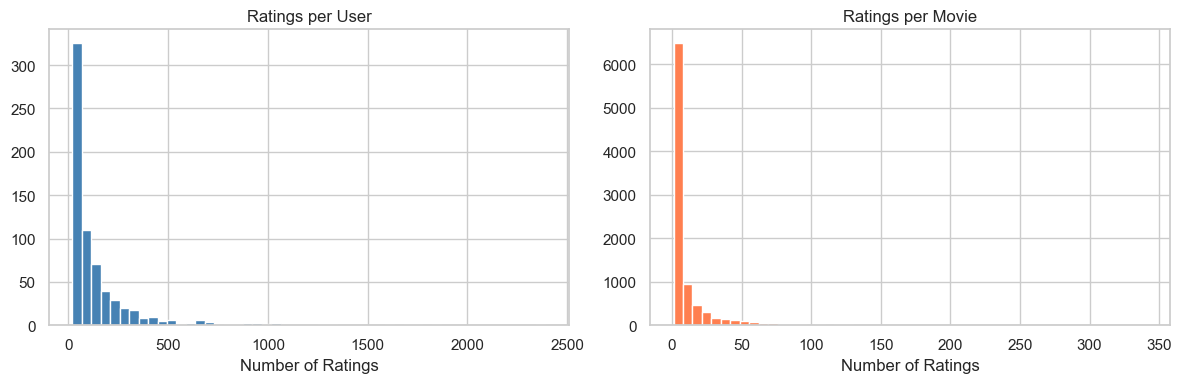

Avg ratings per user  : 149.0
Avg ratings per movie : 11.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ratings_per_user  = ratings.groupby('userId')['rating'].count()
ratings_per_movie = ratings.groupby('movieId')['rating'].count()

axes[0].hist(ratings_per_user, bins=50, color='steelblue')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of Ratings')

axes[1].hist(ratings_per_movie, bins=50, color='coral')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('../data/processed/ratings_per_user_movie.png')
plt.show()

print(f"Avg ratings per user  : {ratings_per_user.mean():.1f}")
print(f"Avg ratings per movie : {ratings_per_movie.mean():.1f}")

In [9]:
# Check how credits/keywords link to metadata via movie id
metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce')
credits['id']  = pd.to_numeric(credits['id'],  errors='coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors='coerce')

meta_ids     = set(metadata['id'].dropna())
credit_ids   = set(credits['id'].dropna())
keyword_ids  = set(keywords['id'].dropna())
link_tmdb    = set(links['tmdbId'].dropna())

print(f"metadata IDs           : {len(meta_ids):,}")
print(f"credits IDs            : {len(credit_ids):,}")
print(f"keywords IDs           : {len(keyword_ids):,}")
print(f"links tmdbId           : {len(link_tmdb):,}")
print(f"metadata ∩ credits     : {len(meta_ids & credit_ids):,}")
print(f"metadata ∩ keywords    : {len(meta_ids & keyword_ids):,}")
print(f"metadata ∩ links       : {len(meta_ids & link_tmdb):,}")

metadata IDs           : 45,433
credits IDs            : 45,432
keywords IDs           : 45,432
links tmdbId           : 45,594
metadata ∩ credits     : 45,432
metadata ∩ keywords    : 45,432
metadata ∩ links       : 45,433


In [10]:
summary = {
    'total_movies'         : len(metadata),
    'total_ratings'        : len(ratings),
    'unique_users'         : ratings['userId'].nunique(),
    'unique_rated_movies'  : ratings['movieId'].nunique(),
    'avg_rating'           : round(ratings['rating'].mean(), 2),
    'missing_overview'     : int(metadata['overview'].isnull().sum()),
    'missing_release_date' : int(metadata['release_date'].isnull().sum()),
}

import json
with open('../data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA summary saved ✅")
print(json.dumps(summary, indent=2))

EDA summary saved ✅
{
  "total_movies": 45466,
  "total_ratings": 100004,
  "unique_users": 671,
  "unique_rated_movies": 9066,
  "avg_rating": 3.54,
  "missing_overview": 954,
  "missing_release_date": 90
}
